# TL;DR

- This is a notebook with a quite short discovery of main crypto assets (those with options on binance): BTC, ETH, SOL, BNB, XRP, DOGE
- 

# Outline

- [Libs](#libs)
- [Data](#data)
- [Returns EDA](#returns-eda)
- [Baseline](#baseline)
- [Strategies](#strategies)

# Libs

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

# Data

In [3]:
df = pd.read_csv('data/spot_data.csv')

In [4]:
df.head()

,date,open_price,high_price,low_price,close_price,volume,symbol
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,23741.687033,BTCUSDT
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369,BTCUSDT
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359,BTCUSDT
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671,BTCUSDT
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751,BTCUSDT


In [7]:
df.columns

Index(['date', 'open_price', 'high_price', 'low_price', 'close_price',
       'volume', 'symbol'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 711260 entries, 0 to 711259
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         711260 non-null  object 
 1   open_price   711260 non-null  float64
 2   high_price   711260 non-null  float64
 3   low_price    711260 non-null  float64
 4   close_price  711260 non-null  float64
 5   volume       711260 non-null  float64
 6   symbol       711260 non-null  object 
dtypes: float64(5), object(2)
memory usage: 38.0+ MB


In [10]:
df.date = pd.to_datetime(df.date)

In [ ]:
# currently there are BTC, ETH, SOL, BNB, XRP, DOGE options on binance
option_symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT']

In [12]:
df = df[df.symbol.isin(option_symbols)]

In [17]:
df = df.reset_index(drop=True)

In [64]:
# .groupby().pct_change() works weird, so using apply() with multiplying by 100
# we might need df with OHLC candles, creating a new DataFrame
ret = df.set_index('date')[['symbol', 'close_price']].groupby('symbol').apply(lambda x: (x/x.shift()-1)*100).reset_index().dropna().rename(columns = {'close_price':'returns'}).set_index('date').copy()

# Returns EDA

<Axes: xlabel='date'>

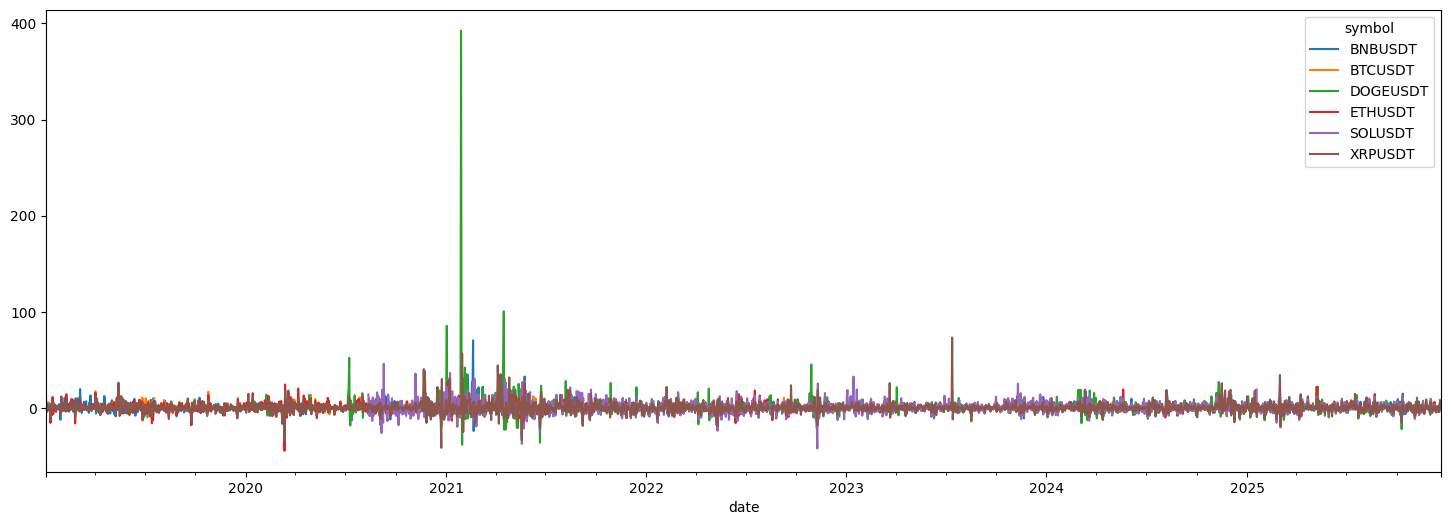

In [66]:
ret.pivot(columns='symbol', values='returns').plot(figsize=(18, 6))

- Looks completely uninformative
- Let's go to histogram 

array([[<Axes: title={'center': 'BNBUSDT'}>,
        <Axes: title={'center': 'BTCUSDT'}>],
       [<Axes: title={'center': 'DOGEUSDT'}>,
        <Axes: title={'center': 'ETHUSDT'}>],
       [<Axes: title={'center': 'SOLUSDT'}>,
        <Axes: title={'center': 'XRPUSDT'}>]], dtype=object)

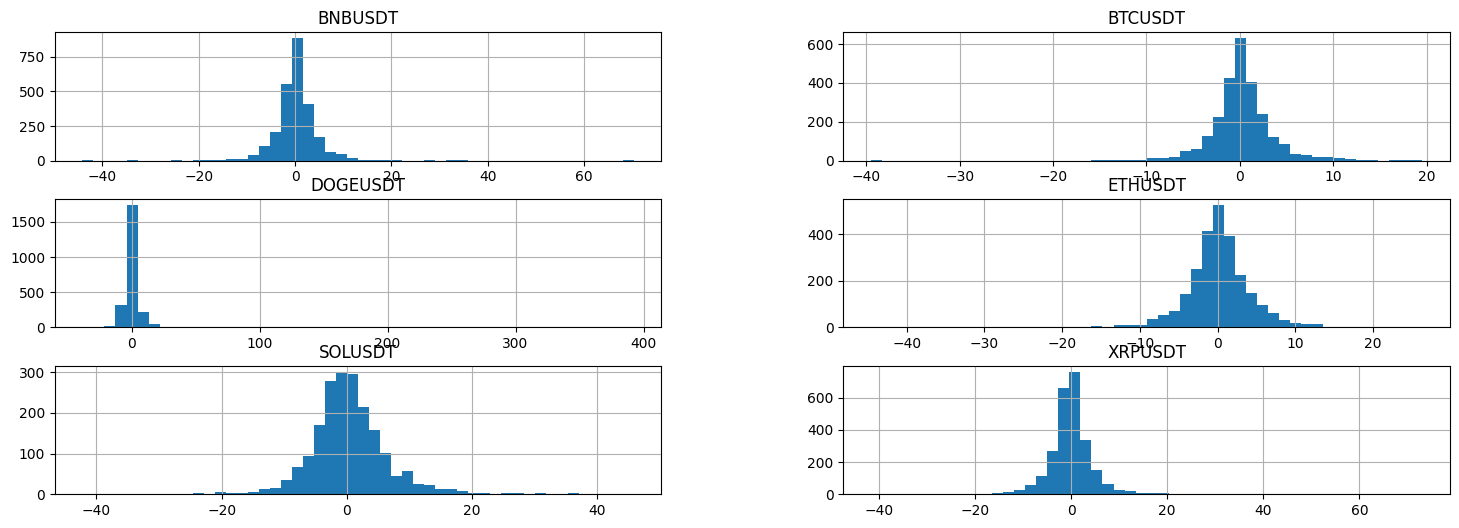

In [67]:
ret.pivot(columns='symbol', values='returns').hist(figsize=(18, 6), bins=50)

- Default pandas (matplotlib) histogram looks horrible
- Let's do something more useful

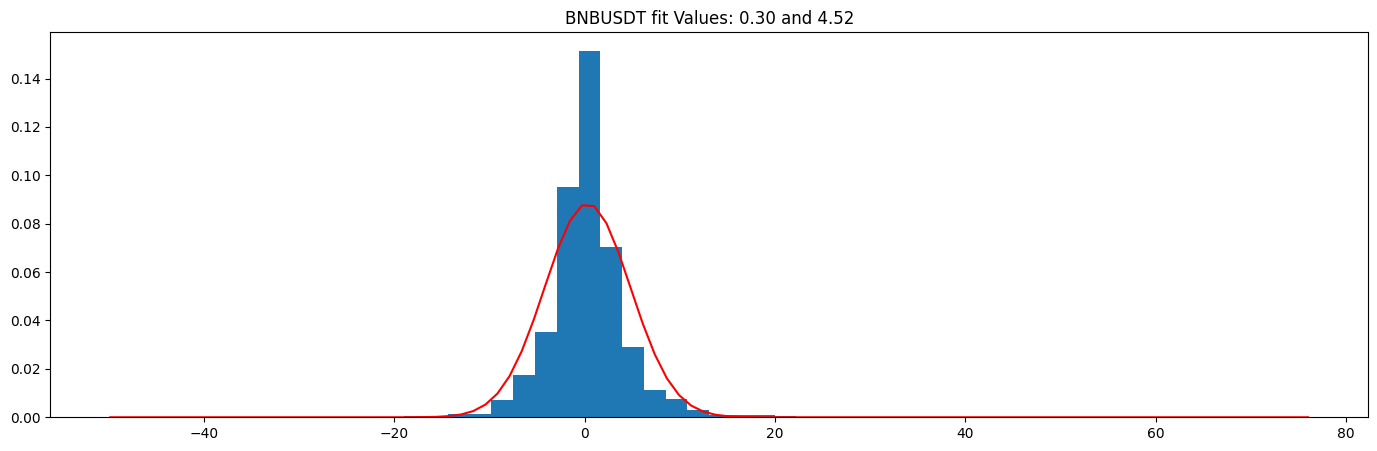

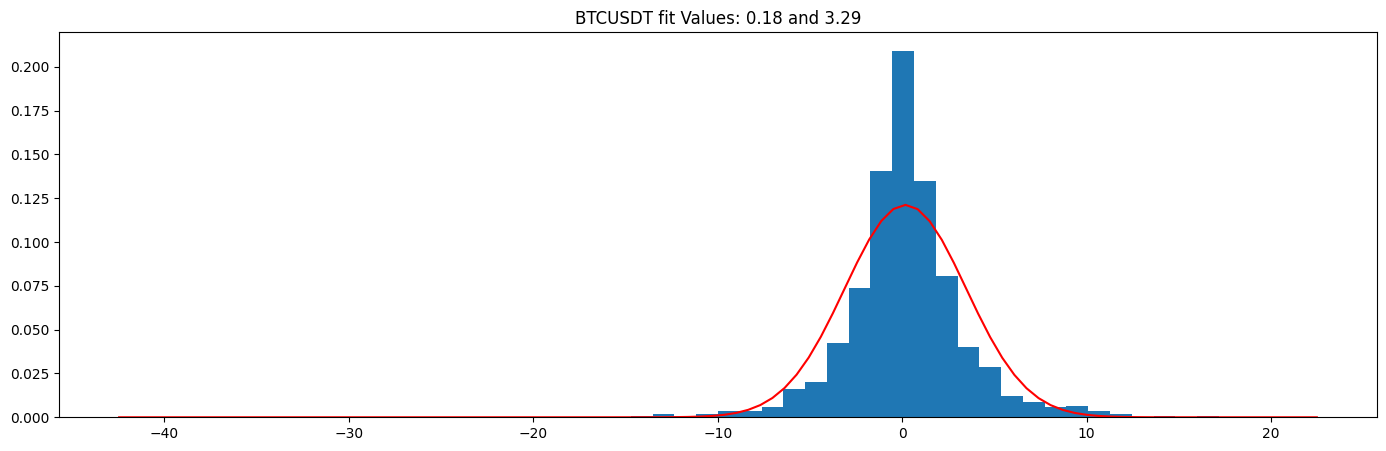

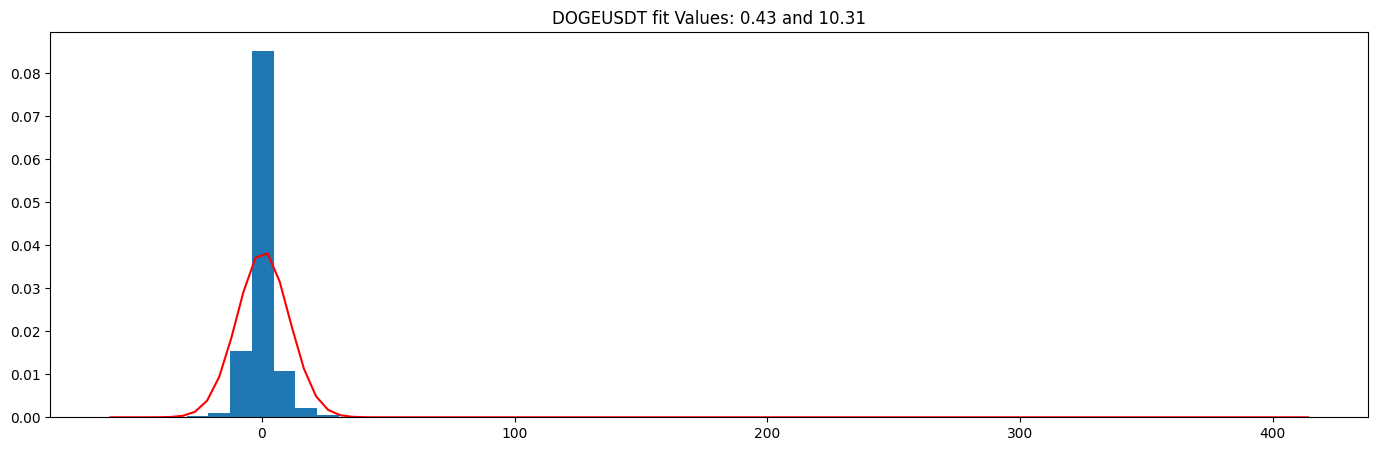

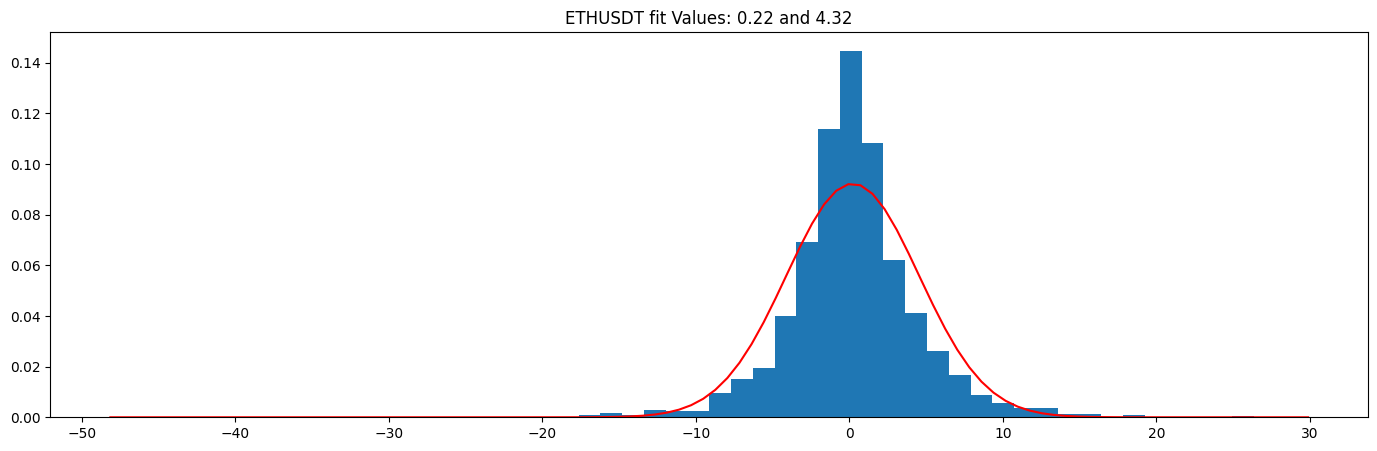

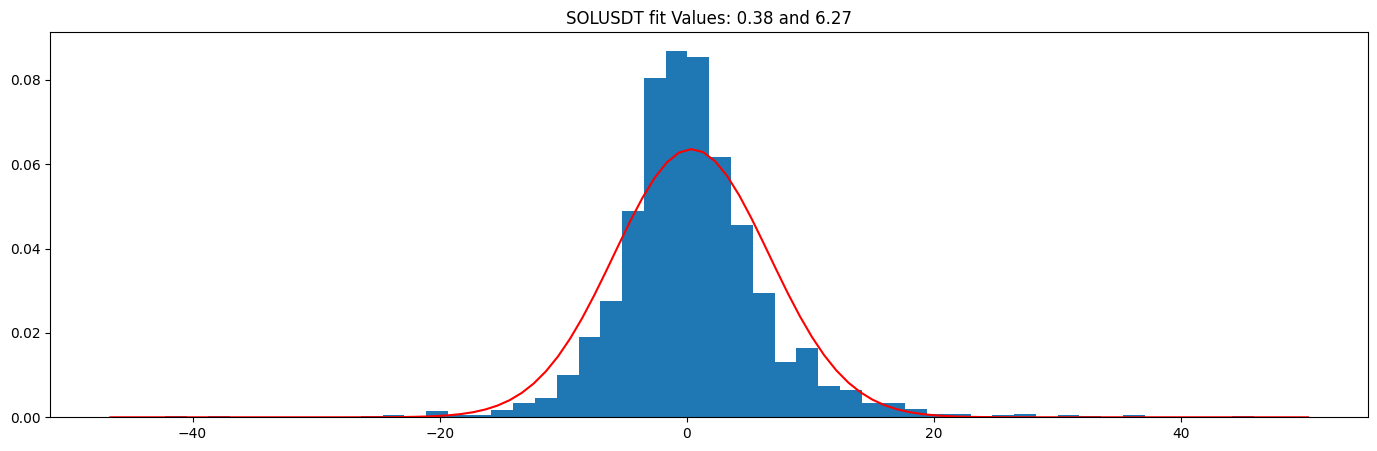

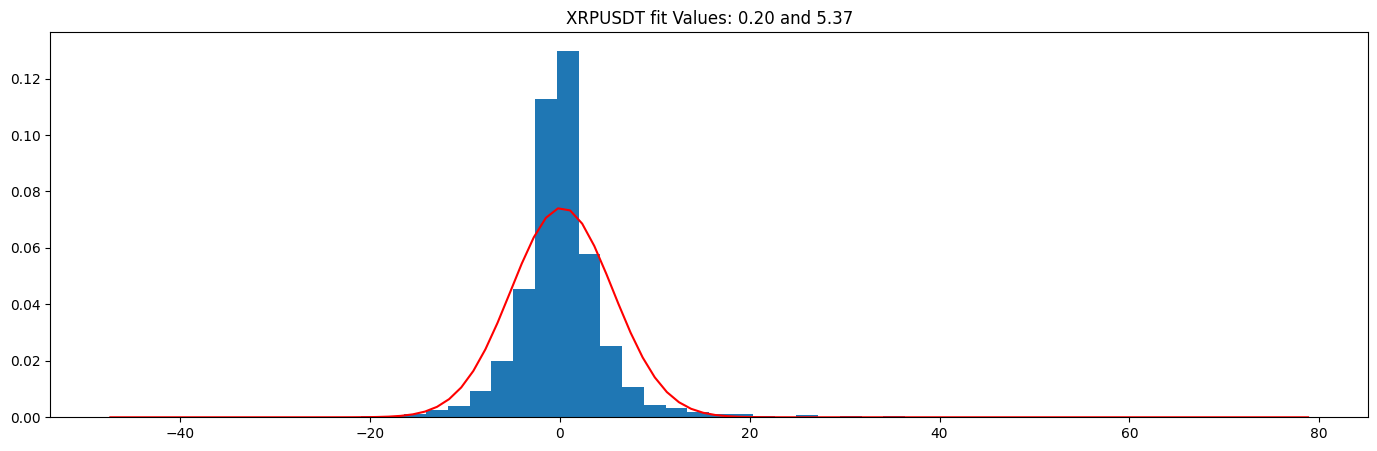

In [68]:
for symbol in ret.symbol.unique():
    
    tmp = ret[ret.symbol == symbol]['returns']

    mu, std = stats.norm.fit(tmp)
    
    plt.figure(figsize=(17,5))
    plt.hist(tmp, bins=50, density=True)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)

    plt.plot(x, p, 'r')
    title = f"{symbol} fit Values: {mu:.2f} and {std:.2f}"
    plt.title(title)

    plt.show()

In [72]:
ret.groupby('symbol').describe()

returns                                                      \
           count      mean        std        min       25%       50%   
symbol                                                                 
BNBUSDT   2546.0  0.295178   4.518315 -44.138077 -1.556955  0.164437   
BTCUSDT   2546.0  0.178705   3.292418 -39.504847 -1.288894  0.056268   
DOGEUSDT  2361.0  0.434617  10.313626 -38.439286 -2.370864 -0.034823   
ETHUSDT   2546.0  0.215533   4.325051 -44.596886 -1.838836  0.104701   
SOLUSDT   1958.0  0.380570   6.276309 -42.247744 -2.970316 -0.002174   
XRPUSDT   2546.0  0.202994   5.374945 -41.646880 -1.949394  0.021963   

                                
               75%         max  
symbol                          
BNBUSDT   1.969779   70.302147  
BTCUSDT   1.546463   19.536139  
DOGEUSDT  2.124743  392.411365  
ETHUSDT   2.156087   26.332887  
SOLUSDT   3.255592   45.871151  
XRPUSDT   1.953486   73.099788

In [76]:
ret.groupby('symbol').apply(pd.DataFrame.skew)

,returns
symbol,
BNBUSDT,1.478063
BTCUSDT,-0.383096
DOGEUSDT,24.132410
ETHUSDT,-0.197382
SOLUSDT,0.588339
XRPUSDT,2.262593


In [77]:
ret.groupby('symbol').apply(pd.DataFrame.kurt)

,returns
symbol,
BNBUSDT,32.184917
BTCUSDT,11.468535
DOGEUSDT,890.627724
ETHUSDT,8.405213
SOLUSDT,6.239019
XRPUSDT,28.379657


- Obviously we won't go deep into non normal distributions with heavy tails (this is not prod level discovery), but, damn, we definitely need t-Student, GED or any other heavy-tailed distribution
- Doge is just a monster with such skewness and kurtosis
- We are going to use quite simple techniques at first, but it is obvious that "ordinary" statistical methods are going to have a hard time

- It is also a good practice to see how statistics evolved through time

In [78]:
WINDOW_SIZE = 365 # using 1 year window

<Axes: xlabel='date'>

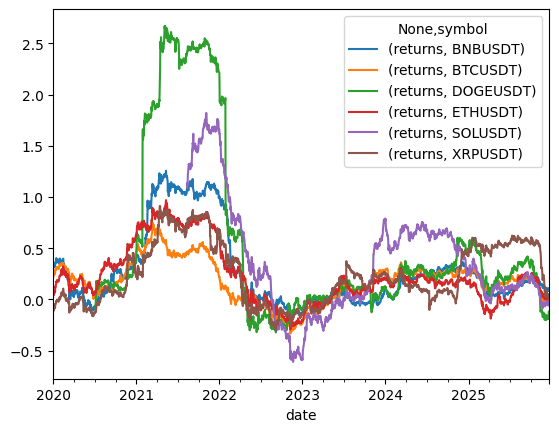

In [85]:
ret.groupby('symbol').rolling(WINDOW_SIZE).mean().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot()

<Axes: xlabel='date'>

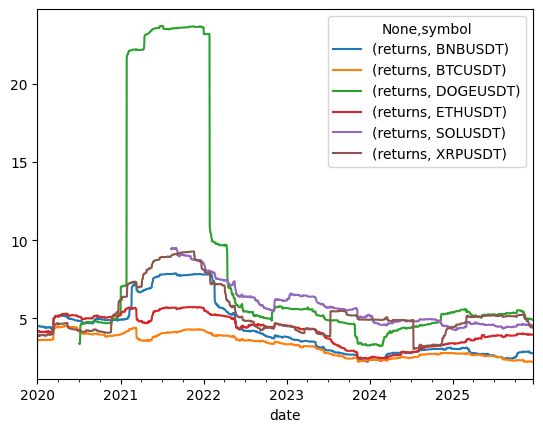

In [86]:
ret.groupby('symbol').rolling(WINDOW_SIZE).std().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot()

<Axes: xlabel='date'>

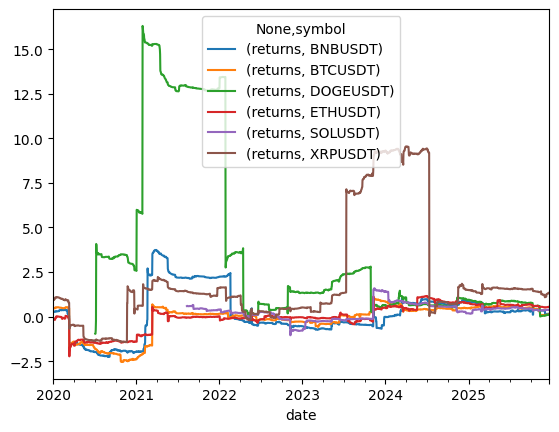

In [91]:
ret.groupby('symbol').rolling(WINDOW_SIZE).skew().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot()

<Axes: xlabel='date'>

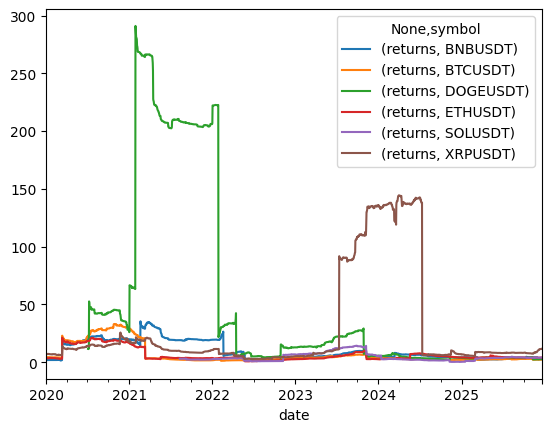

In [92]:
ret.groupby('symbol').rolling(WINDOW_SIZE).kurt().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot()

- Well, it looks like a disaster 
- Mean and standard deviation is one story, but the way skewness and kurtosis changes is a whole other story
- Conclusion is actually quite simple, distribution of returns changes over time and quite rapidly 
- This is very important insight that we can use further

- At last let's see what would we have got with simple buy and hold for each asset

In [100]:
# First, making sure that everything has the same start date (I am just lazy)
ret = ret[ret.index >= ret.reset_index().groupby('symbol')['date'].min().max()]

<Axes: xlabel='date'>

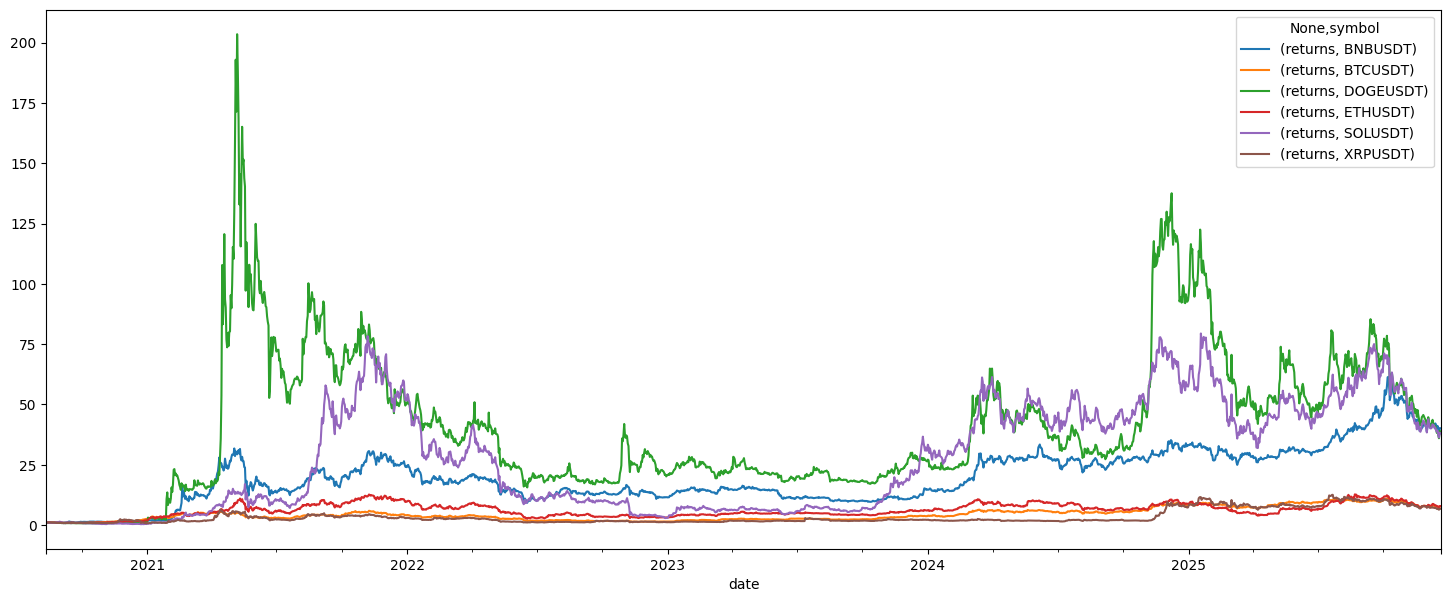

In [108]:
ret.groupby('symbol').apply(lambda x: (1+x/100).cumprod()).reset_index().set_index('date').pivot(columns='symbol').plot(figsize=(18, 7))

- Would have been nice to get 200x...
- Anyway, this is just a fun activity showing how volatile these assets are and how the nature of crypto market changes in no time
- The main challenge is creating not just profitable strategy, but one that keeps up with changing market conditions

# Baseline

- The simplest baseline is an equally weighted long portfolio of these assets

In [113]:
w_baseline = 1/len(ret.symbol.unique())

In [128]:
baseline_portfolio = (ret.pivot(columns = 'symbol') * w_baseline).sum(axis=1)

In [132]:
baseline_portfolio = pd.DataFrame(baseline_portfolio).rename(columns = {0:'returns'})
baseline_portfolio['symbol'] = 'baseline'

In [ ]:
baseline_portfolio = baseline_portfolio[['symbol', 'returns']]

In [137]:
ret = pd.concat([ret, baseline_portfolio], axis = 0)

<Axes: xlabel='date'>

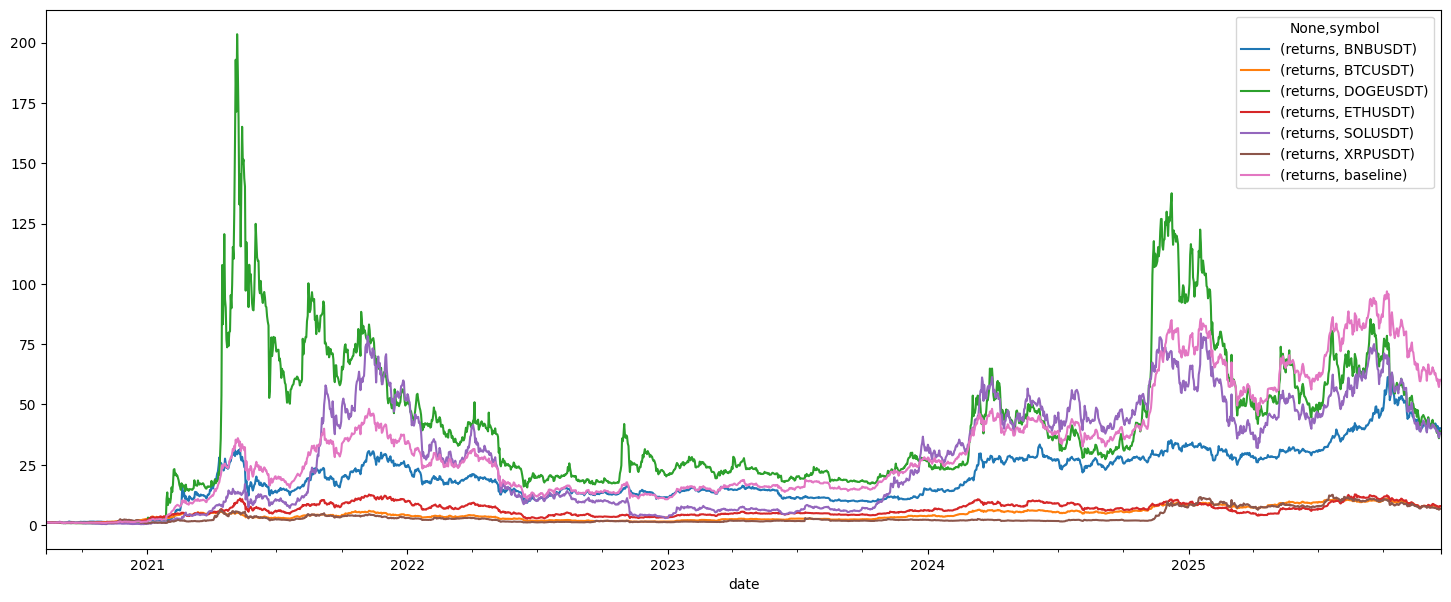

In [138]:
ret.groupby('symbol').apply(lambda x: (1+x/100).cumprod()).reset_index().set_index('date').pivot(columns='symbol').plot(figsize=(18, 7))

- Ok, we have a baseline portfolio
- Now, how would we decide that our strategy is better or worse that buy and hold of baseline portfolio?
- There are a lot of metrics, but I prefer returns to 95% expected shortfall (ES95%) - return to risk ratio (RRR) for future reference

In [163]:
baseline_ret = (1+baseline_portfolio.returns/100).prod()
baseline_es95 = baseline_portfolio[baseline_portfolio.returns < baseline_portfolio.returns.quantile(0.05)].returns.mean()

In [173]:
print(f'''
    For the period from {baseline_portfolio.index.min().date().strftime('%Y-%m-%d')} to {baseline_portfolio.index.max().date().strftime('%Y-%m-%d')} \n
    baseline metrics are: \n
        return is {baseline_ret:.2f}% \n
        ES95% is {baseline_es95:.2f}% \n
        RRR is {baseline_ret / abs(baseline_es95):.2f}
    '''
)


    For the period from 2020-08-12 to 2025-12-21 

    baseline metrics are: 

        return is 59.98% 

        ES95% is -8.94% 

        RRR is 6.71
    


# Strategies

- Well, this is the most difficult part actually
- Let's look at this problem at two different angles 
- The first angle is a optimal portfolio theory. Basically, let's implement Markowitz portfolio theory. Again, I will use a 1 year rolling window basis for weights recalculation
- The second angle is a true cypro bros approach (actually, classic momentum): if EMA 5 > EMA 25 -> buy, weights will be volatility proportioned 
- No short positions allowed (as I said earlier, I am lazy)